
Please fill out:
* Student name: **Justin Mawira, Clive Kinyanjui, Brian Ireri, Faith John, Sharahbil Abdi (Group 3)**
* Student pace: **full time**
* Scheduled project review date/time: 
* Instructor name: **Mwikali**
* Blog post URL:

## Business Problem
Your company has decided to create a new movie studio, but they don’t know anything about creating movies. You are charged with exploring what types of films are currently doing the best at the box office. You must then translate those findings into actionable insights that the head of your company's new movie studio can use to help decide what type of films to create.

In [32]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

# **First dataset** ⬇️


In [5]:
budget_numbers_df = pd.read_csv("../Data/tn.movie_budgets.csv.gz")
budget_numbers_df

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross
0,1,"Dec 18, 2009",Avatar,"$425,000,000","$760,507,625","$2,776,345,279"
1,2,"May 20, 2011",Pirates of the Caribbean: On Stranger Tides,"$410,600,000","$241,063,875","$1,045,663,875"
2,3,"Jun 7, 2019",Dark Phoenix,"$350,000,000","$42,762,350","$149,762,350"
3,4,"May 1, 2015",Avengers: Age of Ultron,"$330,600,000","$459,005,868","$1,403,013,963"
4,5,"Dec 15, 2017",Star Wars Ep. VIII: The Last Jedi,"$317,000,000","$620,181,382","$1,316,721,747"
...,...,...,...,...,...,...
5777,78,"Dec 31, 2018",Red 11,"$7,000",$0,$0
5778,79,"Apr 2, 1999",Following,"$6,000","$48,482","$240,495"
5779,80,"Jul 13, 2005",Return to the Land of Wonders,"$5,000","$1,338","$1,338"
5780,81,"Sep 29, 2015",A Plague So Pleasant,"$1,400",$0,$0


## Analysis & Cleaning (tn budgets)

In [6]:
budget_numbers_df.dtypes


id                    int64
release_date         object
movie                object
production_budget    object
domestic_gross       object
worldwide_gross      object
dtype: object

In [7]:
budget_numbers_df.isnull().sum()


id                   0
release_date         0
movie                0
production_budget    0
domestic_gross       0
worldwide_gross      0
dtype: int64

In [8]:
budget_numbers_df_copy = budget_numbers_df.copy()

budget_numbers_df_copy['production_budget'] = (
    budget_numbers_df_copy['production_budget']
    .str.replace('$', '', regex=False)  # remove dollar sign
    .str.replace(',', '', regex=False)  # remove commas
    .astype(float)                       # convert to float
)
# .astype(float) works well for these columns as they have no nulls

budget_numbers_df_copy['domestic_gross'] = (
    budget_numbers_df_copy['domestic_gross']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)

budget_numbers_df_copy['worldwide_gross'] = (
    budget_numbers_df_copy['worldwide_gross']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)



In [9]:

# Net profit
budget_numbers_df_copy['net_profit'] = budget_numbers_df_copy['worldwide_gross'] - budget_numbers_df_copy['production_budget']

# ROI
budget_numbers_df_copy['ROI'] = budget_numbers_df_copy['net_profit'] / budget_numbers_df_copy['production_budget']


In [10]:
# movies that had the highest profits
budget_numbers_df_copy.sort_values('net_profit', ascending=False).head(20)

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross,net_profit,ROI
0,1,"Dec 18, 2009",Avatar,425000000.0,760507625.0,2.776345e+09,2.351345e+09,5.532577
42,43,"Dec 19, 1997",Titanic,200000000.0,659363944.0,2.208208e+09,2.008208e+09,10.041042
6,7,"Apr 27, 2018",Avengers: Infinity War,300000000.0,678815482.0,2.048134e+09,1.748134e+09,5.827114
5,6,"Dec 18, 2015",Star Wars Ep. VII: The Force Awakens,306000000.0,936662225.0,2.053311e+09,1.747311e+09,5.710167
33,34,"Jun 12, 2015",Jurassic World,215000000.0,652270625.0,1.648855e+09,1.433855e+09,6.669092
66,67,"Apr 3, 2015",Furious 7,190000000.0,353007020.0,1.518723e+09,1.328723e+09,6.993278
26,27,"May 4, 2012",The Avengers,225000000.0,623279547.0,1.517936e+09,1.292936e+09,5.746382
260,61,"Jul 15, 2011",Harry Potter and the Deathly Hallows: Part II,125000000.0,381193157.0,1.341693e+09,1.216693e+09,9.733545
41,42,"Feb 16, 2018",Black Panther,200000000.0,700059566.0,1.348258e+09,1.148258e+09,5.741291
112,13,"Jun 22, 2018",Jurassic World: Fallen Kingdom,170000000.0,417719760.0,1.305773e+09,1.135773e+09,6.681016


### Total Gross
   - the money a movie made worldwide, ie domestic + international
### Net Profit (or Loss)
   - production budget subtracted from the total gross
### Return on Investment
   - financial ratio that measures the profitability of an investment by by comparing its gain or loss relative to its cost

   - represents efficiency; a movie can have the greatest ROI but not necessarily the most profit
   
(eg. returning a profit of $1000 from an investment of $10)

In [11]:
# movies that had the highest losses
budget_numbers_df_copy.sort_values('net_profit', ascending=True).head(20)

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross,net_profit,ROI
2,3,"Jun 7, 2019",Dark Phoenix,350000000.0,42762350.0,149762350.0,-200237650.0,-0.572108
194,95,"Dec 31, 2020",Moonfall,150000000.0,0.0,0.0,-150000000.0,-1.000000
193,94,"Mar 11, 2011",Mars Needs Moms,150000000.0,21392758.0,39549758.0,-110450242.0,-0.736335
341,42,"Jun 14, 2019",Men in Black: International,110000000.0,3100000.0,3100000.0,-106900000.0,-0.971818
352,53,"Apr 27, 2001",Town & Country,105000000.0,6712451.0,10364769.0,-94635231.0,-0.901288
404,5,"Aug 16, 2002",The Adventures of Pluto Nash,100000000.0,4411102.0,7094995.0,-92905005.0,-0.929050
479,80,"Dec 13, 2017",Bright,90000000.0,0.0,0.0,-90000000.0,-1.000000
480,81,"Dec 31, 2019",Army of the Dead,90000000.0,0.0,0.0,-90000000.0,-1.000000
535,36,"Feb 21, 2020",Call of the Wild,82000000.0,0.0,0.0,-82000000.0,-1.000000
477,78,"Apr 21, 2017",The Promise,90000000.0,8224288.0,10551417.0,-79448583.0,-0.882762


In [12]:
# movies that had the highest ROI
budget_numbers_df_copy.sort_values('ROI', ascending=False).head(30)

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross,net_profit,ROI
5745,46,"Jun 30, 1972",Deep Throat,25000.0,45000000.0,45000000.0,44975000.0,1799.000000
5613,14,"Mar 21, 1980",Mad Max,200000.0,8750000.0,99750000.0,99550000.0,497.750000
5492,93,"Sep 25, 2009",Paranormal Activity,450000.0,107918810.0,194183034.0,193733034.0,430.517853
5679,80,"Jul 10, 2015",The Gallows,100000.0,22764410.0,41656474.0,41556474.0,415.564740
5406,7,"Jul 14, 1999",The Blair Witch Project,600000.0,140539099.0,248300000.0,247700000.0,412.833333
5709,10,"May 7, 2004",Super Size Me,65000.0,11529368.0,22233808.0,22168808.0,341.058585
5346,47,"Aug 13, 1942",Bambi,858000.0,102797000.0,268000000.0,267142000.0,311.354312
5773,74,"Feb 26, 1993",El Mariachi,7000.0,2040920.0,2041928.0,2034928.0,290.704000
5676,77,"Oct 1, 1968",Night of the Living Dead,114000.0,12087064.0,30087064.0,29973064.0,262.921614
5210,11,"Nov 21, 1976",Rocky,1000000.0,117235147.0,225000000.0,224000000.0,224.000000


c:\Users\User\anaconda3\envs\learn-env\lib\site-packages\numpy\lib\function_base.py:2526: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar)
c:\Users\User\anaconda3\envs\learn-env\lib\site-packages\numpy\lib\function_base.py:2455: RuntimeWarning: divide by zero encountered in true_divide
  c *= np.true_divide(1, fact)


Text(0.5, 0, 'Release Year')

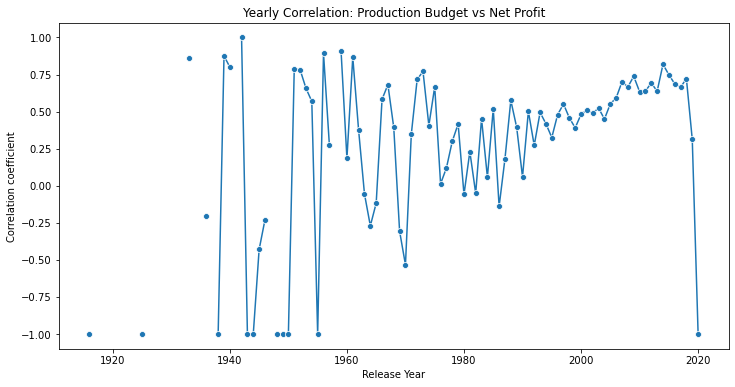

In [70]:
# calculate yearly correlation
budget_numbers_df_copy['release_date'] = pd.to_datetime(
    budget_numbers_df_copy['release_date'], errors='coerce'
)

budget_numbers_df_copy['release_year'] = budget_numbers_df_copy['release_date'].dt.year
budget_numbers_df_clean = budget_numbers_df_copy.dropna(subset=['release_year'])

year_corr_list = []
for year, group in budget_numbers_df_clean.groupby('release_year'):
    corr = group['production_budget'].corr(group['net_profit'])
    year_corr_list.append({'year': year, 'corr': corr})

year_corr_df = pd.DataFrame(year_corr_list)


plt.figure(figsize=(12,6))
sns.lineplot(data=year_corr_df, x='year', y='corr', marker='o')
plt.title('Yearly Correlation: Production Budget vs Net Profit')
plt.ylabel('Correlation coefficient')
plt.xlabel('Release Year')


Text(0.5, 0.98, 'Production Budget vs Net Profit by Year')

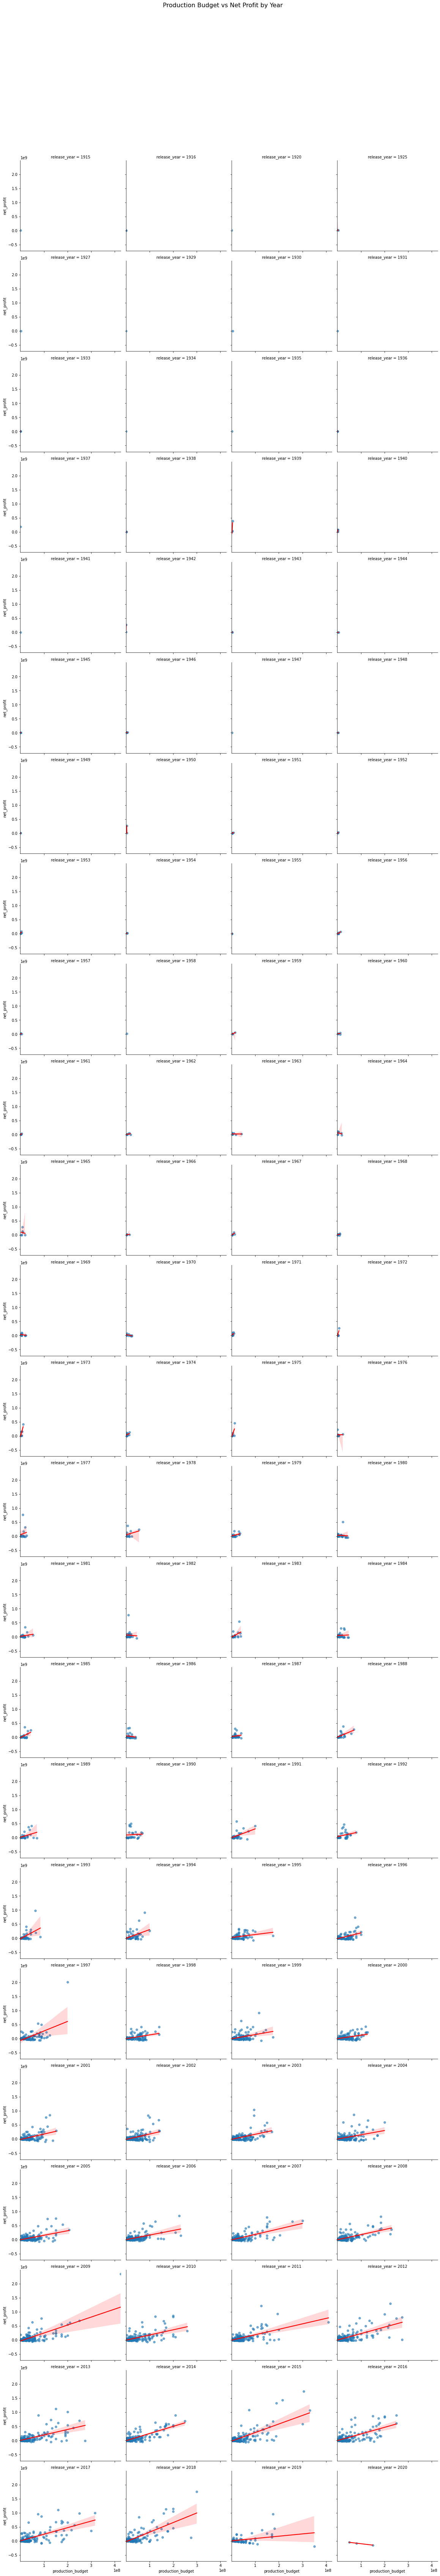

In [68]:

budget_numbers_df_clean['release_year'] = budget_numbers_df_clean['release_year'].astype(int)

# scatter plot
sns.lmplot(
    data=budget_numbers_df_clean,
    x='production_budget',
    y='net_profit',
    col='release_year',
    col_wrap=4,       # plots per row
    height=4,         # each plot
    scatter_kws={'alpha':0.6, 's':30},  
    line_kws={'color':'red'}            
)

plt.subplots_adjust(top=0.92)
plt.suptitle('Production Budget vs Net Profit by Year', fontsize=16)


In [61]:
year_corr_df['decade'] = (year_corr_df['year'] // 10) * 10

decade_corr = year_corr_df.groupby('decade')['corr'].mean().reset_index()
decade_corr

,decade,corr
0,1910,-1.000000
1,1920,-1.000000
2,1930,0.133788
3,1940,-0.357426
4,1950,0.319270
5,1960,0.233109
6,1970,0.322547
7,1980,0.215936
8,1990,0.394959
9,2000,0.570467


- _Higher correlation in a decade means bigger budgets were more strongly tied to bigger profits_

- _Lower correlation means profits were more independent of production budget_

- _Years with very few releases (small sample size) may show volatile correlations, so trends should be interpreted directionally rather than precisely_

- _And of course correlation != causation_

## Insight: Profit vs ROI
Although superhero movies dominate total profit, they rarely appear among the highest ROI films. 
This suggests that large studios benefit from scale, while smaller studios can achieve efficiency with low-budget genre (particularly horror) films.

* _17 movies made profits >$1,000,000,000_

* _6 of the 20 most profitable films were superhero movies_

* _17 of the 20 most profitable movies were from the 2010s_

* _28 movies had an ROI > 100; none of them superhero movies & most with a production budget <$1,000,000_

* _Only 2 of 30 movies with the highest ROI were from the 2010s_

# **Second dataset** ⬇️

In [13]:
# make a connection
conn = sqlite3.connect('../Data/im.db')

# create a cursor object
cur = conn.cursor()

In [14]:
pd.read_sql("""

SELECT name AS Table_Names
FROM sqlite_master
WHERE type = 'table'
            
""", conn)

,Table_Names
0,movie_basics
1,directors
2,known_for
3,movie_akas
4,movie_ratings
5,persons
6,principals
7,writers


In [39]:
imdb_movies = pd.read_sql("""
            
SELECT *
FROM movie_basics
            
""", conn)

imdb_movies

,movie_id,primary_title,original_title,start_year,runtime_minutes,genres
0,tt0063540,Sunghursh,Sunghursh,2013,175.0,"Action,Crime,Drama"
1,tt0066787,One Day Before the Rainy Season,Ashad Ka Ek Din,2019,114.0,"Biography,Drama"
2,tt0069049,The Other Side of the Wind,The Other Side of the Wind,2018,122.0,Drama
3,tt0069204,Sabse Bada Sukh,Sabse Bada Sukh,2018,NaN,"Comedy,Drama"
4,tt0100275,The Wandering Soap Opera,La Telenovela Errante,2017,80.0,"Comedy,Drama,Fantasy"
...,...,...,...,...,...,...
146139,tt9916538,Kuambil Lagi Hatiku,Kuambil Lagi Hatiku,2019,123.0,Drama
146140,tt9916622,Rodolpho Teóphilo - O Legado de um Pioneiro,Rodolpho Teóphilo - O Legado de um Pioneiro,2015,NaN,Documentary
146141,tt9916706,Dankyavar Danka,Dankyavar Danka,2013,NaN,Comedy
146142,tt9916730,6 Gunn,6 Gunn,2017,116.0,None


In [44]:
imdb_ratings = pd.read_sql("""
            
SELECT *
FROM movie_ratings
            
""", conn)

imdb_ratings

,movie_id,averagerating,numvotes
0,tt10356526,8.3,31
1,tt10384606,8.9,559
2,tt1042974,6.4,20
3,tt1043726,4.2,50352
4,tt1060240,6.5,21
...,...,...,...
73851,tt9805820,8.1,25
73852,tt9844256,7.5,24
73853,tt9851050,4.7,14
73854,tt9886934,7.0,5


In [16]:
pd.read_sql("""
            
SELECT *
FROM movie_basics
JOIN movie_ratings USING (movie_id)
GROUP BY movie_basics.movie_id, movie_basics.primary_title
ORDER BY averagerating DESC
            
""", conn)

,movie_id,primary_title,original_title,start_year,runtime_minutes,genres,averagerating,numvotes
0,tt10176328,Exteriores: Mulheres Brasileiras na Diplomacia,Exteriores: Mulheres Brasileiras na Diplomacia,2018,52.0,Documentary,10.0,5
1,tt10378660,The Dark Knight: The Ballad of the N Word,The Dark Knight: The Ballad of the N Word,2018,129.0,"Comedy,Drama",10.0,5
2,tt1770682,Freeing Bernie Baran,Freeing Bernie Baran,2010,100.0,"Crime,Documentary",10.0,5
3,tt2632430,Hercule contre Hermès,Hercule contre Hermès,2012,72.0,Documentary,10.0,5
4,tt4109192,I Was Born Yesterday!,I Was Born Yesterday!,2015,31.0,Documentary,10.0,6
...,...,...,...,...,...,...,...,...
73851,tt8446392,La Scelta Impossibile,La Scelta Impossibile,2018,64.0,Drama,1.0,5
73852,tt8654080,Overdose of Gore: Crime born Crime,Overdose of Gore: Crime born Crime,2015,46.0,Horror,1.0,21
73853,tt9005484,Roofied: The Lethal Dose,Roofied: The Lethal Dose,2019,NaN,Drama,1.0,112
73854,tt9352262,The Defender,The Defender,2018,88.0,Drama,1.0,16


In [30]:
profit_movies = pd.read_sql("""

SELECT *
FROM movie_basics AS mb
JOIN movie_ratings AS mr
  ON mb.movie_id = mr.movie_id
WHERE (mb.primary_title = 'Beauty and the Beast' AND mb.start_year = 2017)
   OR (mb.primary_title = 'Frozen' AND mb.start_year = 2013)
   OR mb.primary_title IN (
    'The Fate of the Furious',
    'Furious 7',
    'Aquaman',
    'Iron Man 3',
    'Incredibles 2',
    'Minions',
    'Black Panther',
    'Avengers: Age of Ultron',
    'Avengers: Infinity War',
    'The Avengers',
    'Jurassic World: Fallen Kingdom',
    'Jurassic World'
)
GROUP BY mb.movie_id, mb.primary_title
ORDER BY mr.averagerating DESC

""", conn)

profit_movies


,movie_id,primary_title,original_title,start_year,runtime_minutes,genres,movie_id,averagerating,numvotes
0,tt4154756,Avengers: Infinity War,Avengers: Infinity War,2018,149.0,"Action,Adventure,Sci-Fi",tt4154756,8.5,670926
1,tt0848228,The Avengers,The Avengers,2012,143.0,"Action,Adventure,Sci-Fi",tt0848228,8.1,1183655
2,tt3606756,Incredibles 2,Incredibles 2,2018,118.0,"Action,Adventure,Animation",tt3606756,7.7,203510
3,tt2294629,Frozen,Frozen,2013,102.0,"Adventure,Animation,Comedy",tt2294629,7.5,516998
4,tt1825683,Black Panther,Black Panther,2018,134.0,"Action,Adventure,Sci-Fi",tt1825683,7.3,516148
5,tt2395427,Avengers: Age of Ultron,Avengers: Age of Ultron,2015,141.0,"Action,Adventure,Sci-Fi",tt2395427,7.3,665594
6,tt1300854,Iron Man 3,Iron Man Three,2013,130.0,"Action,Adventure,Sci-Fi",tt1300854,7.2,692794
7,tt2771200,Beauty and the Beast,Beauty and the Beast,2017,129.0,"Family,Fantasy,Musical",tt2771200,7.2,238325
8,tt2820852,Furious 7,Furious Seven,2015,137.0,"Action,Crime,Thriller",tt2820852,7.2,335074
9,tt1477834,Aquaman,Aquaman,2018,143.0,"Action,Adventure,Fantasy",tt1477834,7.1,263328


In [31]:
profit_movies['genres'].value_counts()

Action,Adventure,Sci-Fi       7
Adventure,Animation,Comedy    2
Action,Crime,Thriller         2
Action,Adventure,Animation    1
Family,Fantasy,Musical        1
Action,Adventure,Fantasy      1
Name: genres, dtype: int64

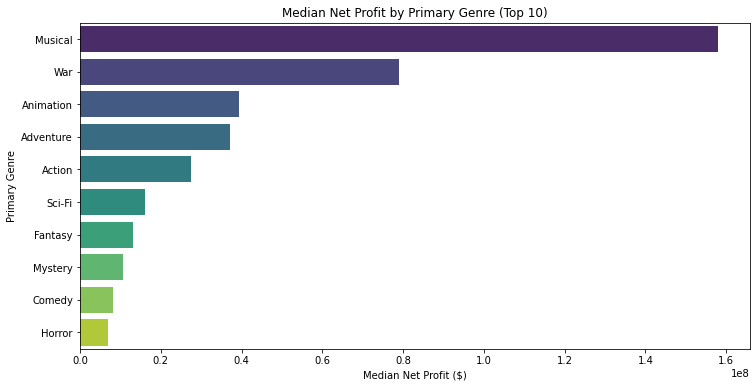

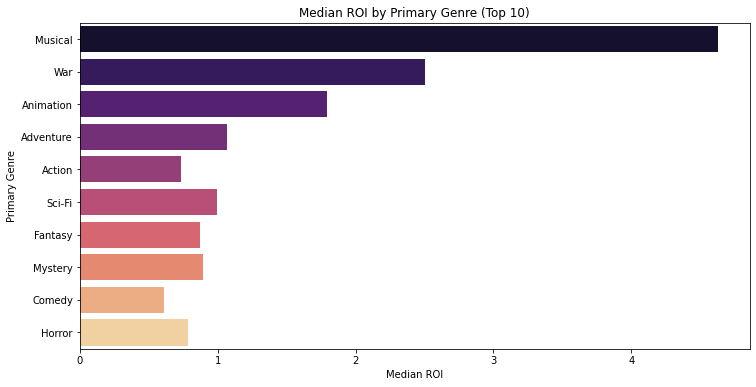

In [73]:
movies_merged = pd.merge(
    budget_numbers_df_copy,
    imdb_movies[['primary_title', 'genres']],  
    left_on='movie',                           # movie title in TN budgets
    right_on='primary_title',                  # movie title in IMDb
    how='left'                                 # keeps all budget movies
)
# create primary genre
movies_merged['primary_genre'] = movies_merged['genres'].str.split(',').str[0]

# average net profit and ROI
primary_genre_summary = movies_merged.groupby('primary_genre')[['net_profit', 'ROI']].median().sort_values('net_profit', ascending=False)

# top 10
top_genres = primary_genre_summary.head(10).index
top_genre_summary = primary_genre_summary.loc[top_genres]


plt.figure(figsize=(12,6))
sns.barplot(
    data=top_genre_summary.reset_index(),
    x='net_profit',
    y='primary_genre',
    palette='viridis'
)
plt.title('Median Net Profit by Primary Genre (Top 10)')
plt.xlabel('Median Net Profit ($)')
plt.ylabel('Primary Genre')
plt.show()

plt.figure(figsize=(12,6))
sns.barplot(
    data=top_genre_summary.reset_index(),
    x='ROI',
    y='primary_genre',
    palette='magma'
)
plt.title('Median ROI by Primary Genre (Top 10)')
plt.xlabel('Median ROI')
plt.ylabel('Primary Genre')
plt.show()

# we define a movie’s primary genre as the first listed genre to enable consistent aggregation and reduce the messiness of having to deal w >300 genres


## Insight

* _The tables from the imdb dataset do not have revenue data_

* _The only significant metric is ratings_

* _Of the 14 most profitable movies that appear on the imdb database, the average rating ranges from 8.5 to 6.2 for Avengers: Infinity War & Jurassic World: Fallen Kingdom respectively_

* _8.5 doesn't make the top 3,600 and 6.2 doesn't make the top 40,000 in terms of IMDb ratings_

* _High box office success != critical acclaim. Studios don’t need top-tier ratings to be profitable_

* _And the most common primary genre among high-profit films is Action_

# **Third dataset** ⬇️


In [18]:
boxoffice_df = pd.read_csv("../Data/bom.movie_gross.csv.gz")
boxoffice_df

,title,studio,domestic_gross,foreign_gross,year
0,Toy Story 3,BV,415000000.0,652000000,2010
1,Alice in Wonderland (2010),BV,334200000.0,691300000,2010
2,Harry Potter and the Deathly Hallows Part 1,WB,296000000.0,664300000,2010
3,Inception,WB,292600000.0,535700000,2010
4,Shrek Forever After,P/DW,238700000.0,513900000,2010
...,...,...,...,...,...
3382,The Quake,Magn.,6200.0,NaN,2018
3383,Edward II (2018 re-release),FM,4800.0,NaN,2018
3384,El Pacto,Sony,2500.0,NaN,2018
3385,The Swan,Synergetic,2400.0,NaN,2018


## Analysis & cleaning (bom gross)

In [19]:
boxoffice_df.isnull().sum()


title                0
studio               5
domestic_gross      28
foreign_gross     1350
year                 0
dtype: int64

In [20]:
boxoffice_df.dtypes


title              object
studio             object
domestic_gross    float64
foreign_gross      object
year                int64
dtype: object

In [21]:
boxoffice_df_copy = boxoffice_df.copy()

# Convert column to numeric
boxoffice_df_copy['foreign_gross'] = pd.to_numeric(boxoffice_df_copy['foreign_gross'], errors='coerce')


In [22]:
# Total gross
boxoffice_df_copy['total_gross'] = boxoffice_df_copy['domestic_gross'] + boxoffice_df_copy['foreign_gross']

In [23]:
# highest grossing movies
boxoffice_df_copy.sort_values('total_gross', ascending=False).head(20)

,title,studio,domestic_gross,foreign_gross,year,total_gross
727,Marvel's The Avengers,BV,623400000.0,895500000.0,2012,1.518900e+09
1875,Avengers: Age of Ultron,BV,459000000.0,946400000.0,2015,1.405400e+09
3080,Black Panther,BV,700100000.0,646900000.0,2018,1.347000e+09
328,Harry Potter and the Deathly Hallows Part 2,WB,381000000.0,960500000.0,2011,1.341500e+09
2758,Star Wars: The Last Jedi,BV,620200000.0,712400000.0,2017,1.332600e+09
3081,Jurassic World: Fallen Kingdom,Uni.,417700000.0,891800000.0,2018,1.309500e+09
1127,Frozen,BV,400700000.0,875700000.0,2013,1.276400e+09
2759,Beauty and the Beast (2017),BV,504000000.0,759500000.0,2017,1.263500e+09
3082,Incredibles 2,BV,608600000.0,634200000.0,2018,1.242800e+09
1128,Iron Man 3,BV,409000000.0,805800000.0,2013,1.214800e+09


In [24]:
# lowest grossing movies
boxoffice_df_copy.sort_values('total_gross', ascending=True).head(20)

,title,studio,domestic_gross,foreign_gross,year,total_gross
721,To Die Like a Man,Strand,4000.0,900.0,2011,4900.0
715,Aurora,CGld,5700.0,5100.0,2011,10800.0
1110,Cirkus Columbia,Strand,3500.0,9500.0,2012,13000.0
322,The Thorn in the Heart,Osci.,7400.0,10500.0,2010,17900.0
711,I'm Glad My Mother is Alive,Strand,8700.0,13200.0,2011,21900.0
321,Picture Me,Strand,12000.0,10400.0,2010,22400.0
320,Nenette,Kino,18000.0,5400.0,2010,23400.0
705,Brotherhood (2011),P4,19700.0,12700.0,2011,32400.0
318,Daddy Longlegs,IFC,21800.0,11500.0,2010,33300.0
1835,Policeman,Crnth,11300.0,27000.0,2014,38300.0


## Insight

* _The top 3 highest-grossing films (total gross) are all superhero movies_

* _7 of the top 20 are superhero movies_

* _4 of the 20 are animated movies_

* _12 of the top 20 films are from the same studio - BV_

* _The box office database doesn't reveal profitability or ROI bc there's no column for production budget_

## Business Recommendations

Large studio: Invest in mid-to-high budget franchise films (/popular IP like Harry Potter) to maximize absolute profit

Smaller studio: Invest in low-budget genre films (like musicals & horror) to maximize ROI and reduce downside risk

## Data Limitations
- IMDb lacks revenue data, limiting profitability analysis
- BOM lacks production budgets, preventing ROI calculations
- Genre classification is incomplete across datasets
- Genre labeling inconsistency across IMDb
- Title matching across datasets may introduce errors
- Marketing costs are excluded (affects true ROI)